In [1]:
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from dotenv import load_dotenv

load_dotenv()

NEWS_API_KEY = os.getenv("NEWS_API_KEY")
FRED_API_KEY = os.getenv("FRED_API_KEY")
ALPHA_VANTAGE_API_KEY = os.getenv("ALPHA_VANTAGE_API_KEY")

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests

from newsapi import NewsApiClient

from fredapi import Fred

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb

from catboost import CatBoostClassifier

import joblib

c:\Users\happy\Desktop\STUFF\KhPI\Semester_8\Thesis\Stock-Market-Forecasting-Component\hf-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(model_name)

newsapi = NewsApiClient(api_key=NEWS_API_KEY)
fred = Fred(api_key=FRED_API_KEY)

ticker, macro, start_date, end_date = "AAPL", "FEDFUNDS", "2020-01-01", "2026-12-31"
news_path = "data/raw/raw_analyst_ratings.csv"

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8394.12it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
def save_sentiment_csv(ticker):
    url = "https://www.alphavantage.co/query"
    params = {"function": "NEWS_SENTIMENT", "tickers": ticker,
              "time_from": "20200101T0000", "apikey": ALPHA_VANTAGE_API_KEY}
    data = requests.get(url, params=params).json()

    alpha_df = pd.DataFrame(data["feed"])
    alpha_df.to_csv(f"data/raw/{ticker}_sentiment.csv", index=False)

def get_sentiment_score(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    outputs = sentiment_model(**inputs)
    prediction = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    probs = prediction.detach().numpy()[0]
    sentiment_score = probs[0] - probs[1]

    return sentiment_score

def get_technical(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date)

    df.dropna(inplace=True)
    df = df.xs(ticker, axis=1, level=1)
    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()

    return df

def get_macro(macro, start_date, end_date):
    return fred.get_series(macro, start_date, end_date).to_frame(name=macro)

def merge_macro(df, macro):
    df = df.merge(macro, left_index=True, right_index=True, how='left')
    return df

def get_sentiment_kaggle(ticker, start_date, end_date):
    kaggle_df = pd.read_csv(news_path, encoding="latin1", index_col=0)
    kaggle_df.drop(columns=['url','publisher'],inplace=True)

    kaggle_df = kaggle_df[kaggle_df['stock'] == ticker].copy()

    kaggle_df['date'] = kaggle_df['date'].astype(str).str.strip()
    kaggle_df['date'] = pd.to_datetime(kaggle_df['date'], errors='coerce', format="%Y-%m-%d %H:%M:%S", utc=True)

    kaggle_df['date'] = pd.to_datetime(kaggle_df['date'], errors='coerce', utc=True)
    kaggle_df['date'] = kaggle_df['date'].dt.tz_localize(None)
    kaggle_df['date'] = kaggle_df['date'].dt.normalize()
    kaggle_df = kaggle_df[kaggle_df['date'].between(start_date, end_date)].copy()

    kaggle_df = kaggle_df.rename(columns={'headline': 'title'})

    kaggle_df['sentiment'] = kaggle_df['title'].apply(lambda x: get_sentiment_score(x))
    kaggle_df['sentiment'] = pd.to_numeric(kaggle_df['sentiment'], errors='coerce')

    return kaggle_df

def get_sentiment_newsapi(q):
    newsapi_df = pd.DataFrame(newsapi.get_everything(q=q, language='en', sort_by='relevancy')['articles'])

    newsapi_df['date'] = pd.to_datetime(newsapi_df['publishedAt']).dt.date
    newsapi_df['sentiment'] = newsapi_df['title'].apply(lambda x: get_sentiment_score(x))
    newsapi_df['sentiment'] = pd.to_numeric(newsapi_df['sentiment'], errors='coerce')

    return newsapi_df

def aggregate_daily_sentiment(news_df):
    daily = news_df.groupby(news_df['date'].dt.date).agg({
        'sentiment': ['mean', 'min', 'max', 'std', 'count']})
    
    daily.columns = ['_'.join(col).strip() for col in daily.columns.values]
    daily['sentiment_std'] = daily['sentiment_std'].fillna(0)
    
    return daily

def merge_sentiment(df, daily_sentiment_df):
    df = df.merge(daily_sentiment_df, left_index=True, right_index=True, how='left')
    return df

def dump_model(model, filename):
    path = os.path.join("models", filename)
    joblib.dump(model, "models/AAPL_xgb.pkl")

def load_model(filename):
    return joblib.load(os.path.join("models", filename))

def get_master_df(ticker, macro, start_date, end_date):
    master_df = get_technical(ticker, start_date, end_date)

    fed_data = get_macro(macro, start_date, end_date)
    master_df = merge_macro(master_df, fed_data)

    master_df = master_df.rename(columns={macro: 'macro'})

    raw_news = get_sentiment_kaggle(ticker, start_date, end_date)
    daily_mood = aggregate_daily_sentiment(raw_news)
    master_df = merge_sentiment(master_df, daily_mood)

    last_news_date = daily_mood.index.max()
    master_df = master_df.loc[:last_news_date]

    master_df.ffill(inplace=True)
    master_df.dropna(inplace=True)

    return master_df

def get_no_sentiment_master_df(ticker, macro, start_date, end_date):
    master_df = get_technical(ticker, start_date, end_date)

    fed_data = get_macro(macro, start_date, end_date)
    master_df = merge_macro(master_df, fed_data)

    master_df = master_df.rename(columns={macro: 'macro'})

    master_df.ffill(inplace=True)
    master_df.dropna(inplace=True)

    return master_df

def prepare_data(threshold):
    df = no_sentiment_df[['Open','High','Low','Close','Volume','macro','SMA_20','SMA_50']].copy()

    df['volatility_10'] = df['Close'].rolling(10).std()
    df['momentum_5'] = df['Close'].pct_change(5)

    df['return'] = df['Close'].pct_change().shift(-1)
    df['target'] = (df['return'] > threshold).astype(int)

    df = df.dropna()

    X = df.drop(columns=['target', 'return'])
    y = df['target']

    return train_test_split(X, y, test_size=0.2, shuffle=False), X.columns

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    baseline = (y_test == y_test.mode()[0]).mean()

    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    pred_rate = np.mean(preds)

    return acc, baseline, precision_1, recall_1, f1_1, pred_rate

def run_experiments(thresholds):
    results = []
    for t in thresholds:
        (X_train, X_test, y_train, y_test), cols = prepare_data(t)
        scale = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1

        models = {
            "LogReg": LogisticRegression(max_iter=1000),
            "RF": RandomForestClassifier(class_weight='balanced', random_state=42),
            "ET": ExtraTreesClassifier(class_weight='balanced', random_state=42),
            "XGB": xgb.XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                scale_pos_weight=scale, random_state=42),
            "LGBM": lgb.LGBMClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                class_weight='balanced', random_state=42),
            "CB": CatBoostClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1, scale_pos_weight=scale,
                random_state=42, verbose=0, allow_writing_files=False)}

        for name, model in models.items():
            acc, base, p, r, f1, pr = evaluate_model(model, X_train, X_test, y_train, y_test)
            results.append({
                "model": name, "threshold": t,
                "accuracy": acc, "baseline": base,
                "precision_1": p, "recall_1": r, "f1_1": f1,
                "predicted_1_rate": pr})

    return pd.DataFrame(results)

no_sentiment_df = get_no_sentiment_master_df(ticker, macro, "2000-01-01", "2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
reg_df = no_sentiment_df[['Open','High','Low','Close','Volume','macro','SMA_20','SMA_50']].copy()

reg_df['volatility_10'] = reg_df['Close'].rolling(10).std()
reg_df['momentum_5'] = reg_df['Close'].pct_change(5)

reg_df = reg_df.dropna()

reg_df['Target'] = reg_df['Close'].pct_change().shift(-1)
reg_df.dropna(inplace=True)

y = reg_df['Target']
X = reg_df.drop(columns=['Target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

xgb_regressor = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_regressor.fit(X_train, y_train)
preds = xgb_regressor.predict(X_test)

print(r2_score(y_test, preds))

reg_df = reg_df.iloc[-len(X_test):].copy()
reg_df['Shift'] = preds
reg_df['Predicted'] = reg_df['Close'] + reg_df['Shift']
reg_df['Target'] = reg_df['Close'].pct_change().shift(-1)

print("MSE:", mean_squared_error(y_test, preds))

-1.0779133762824316
MSE: 0.0006414719929126895


[*********************100%***********************]  1 of 1 completed
C:\Users\happy\AppData\Local\Temp\ipykernel_12556\8026747.py:101: Pandas4Warning: Slicing with a datetime.date object is deprecated. Explicitly cast to Timestamp instead.
  master_df = master_df.loc[:last_news_date]


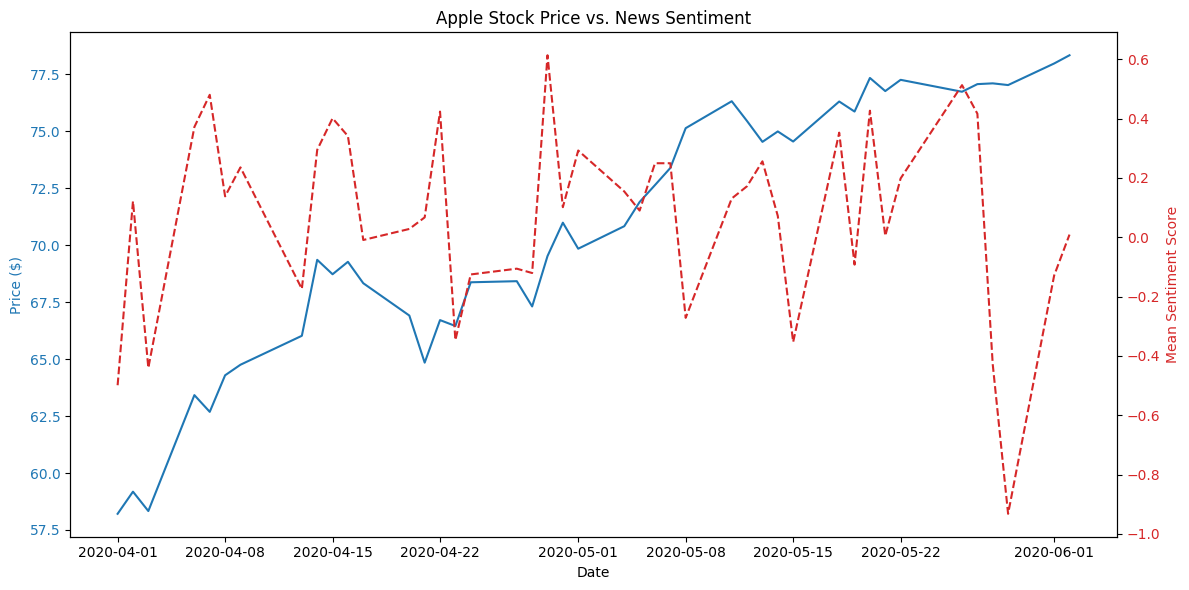

In [5]:
master_df = get_master_df(ticker, macro, start_date, end_date)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)', color='tab:blue')
ax1.plot(master_df.index, master_df['Close'], color='tab:blue', label='AAPL Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Mean Sentiment Score', color='tab:red')
ax2.plot(master_df.index, master_df['sentiment_mean'], color='tab:red', linestyle='--', label='Sentiment')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Apple Stock Price vs. News Sentiment')
fig.tight_layout()
plt.show()

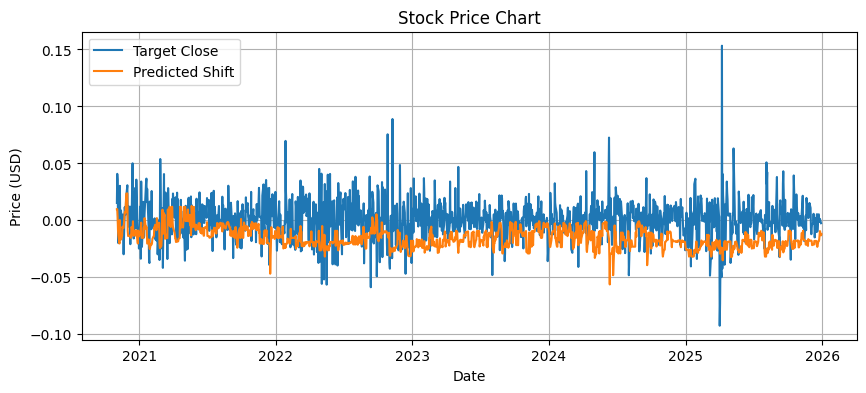

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(reg_df['Target'], label='Target Close')
plt.plot(reg_df['Shift'], label='Predicted Shift')
plt.title('Stock Price Chart')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc=2)
plt.grid()
plt.show()

In [7]:
run_experiments([0.002, 0.003, 0.005, 0.01])

[LightGBM] [Info] Number of positive: 2448, number of negative: 2736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2391
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,model,threshold,accuracy,baseline,precision_1,recall_1,f1_1,predicted_1_rate
0,LogReg,0.002,0.531636,0.531636,0.000000,0.000000,0.000000,0.000000
1,RF,0.002,0.533179,0.531636,1.000000,0.003295,0.006568,0.001543
2,ET,0.002,0.533179,0.531636,1.000000,0.003295,0.006568,0.001543
3,XGB,0.002,0.533951,0.531636,0.800000,0.006590,0.013072,0.003858
4,LGBM,0.002,0.527778,0.531636,0.368421,0.011532,0.022364,0.014660
5,CB,0.002,0.533951,0.531636,1.000000,0.004942,0.009836,0.002315
6,LogReg,0.003,0.562500,0.562500,0.000000,0.000000,0.000000,0.000000
7,RF,0.003,0.564043,0.562500,1.000000,0.003527,0.007030,0.001543
8,ET,0.003,0.564043,0.562500,1.000000,0.003527,0.007030,0.001543
9,XGB,0.003,0.565586,0.562500,0.611111,0.019400,0.037607,0.013889


[LightGBM] [Info] Number of positive: 1570, number of negative: 3614
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2391
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

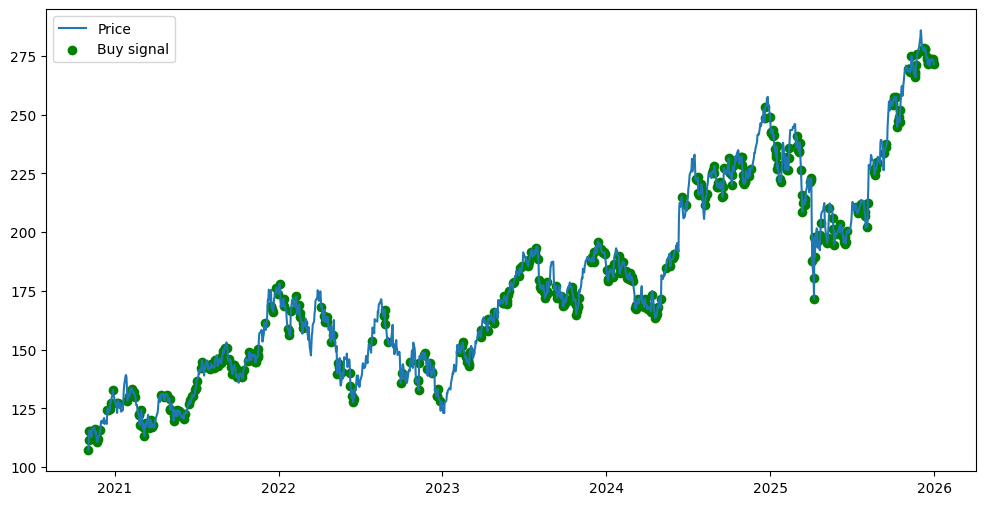

In [8]:
(X_train, X_test, y_train, y_test), cols = prepare_data(0.01)
model_plot = lgb.LGBMClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                class_weight='balanced', random_state=42)
model_plot.fit(X_train, y_train)
preds = model_plot.predict(X_test)

df_plot = no_sentiment_df.copy()

df_plot = df_plot.iloc[-len(y_test):]
df_plot['prediction'] = preds

plt.figure(figsize=(12,6))
plt.plot(df_plot['Close'], label='Price')

buy_signals = df_plot[df_plot['prediction'] == 1]

plt.scatter(buy_signals.index, buy_signals['Close'], color='green', label='Buy signal')

plt.legend()
plt.show()

R2: -2.620788292530556
MSE: 0.0035369666753259383
Directional accuracy: 0.33195020746887965
Baseline MSE: 0.0011775109641660722


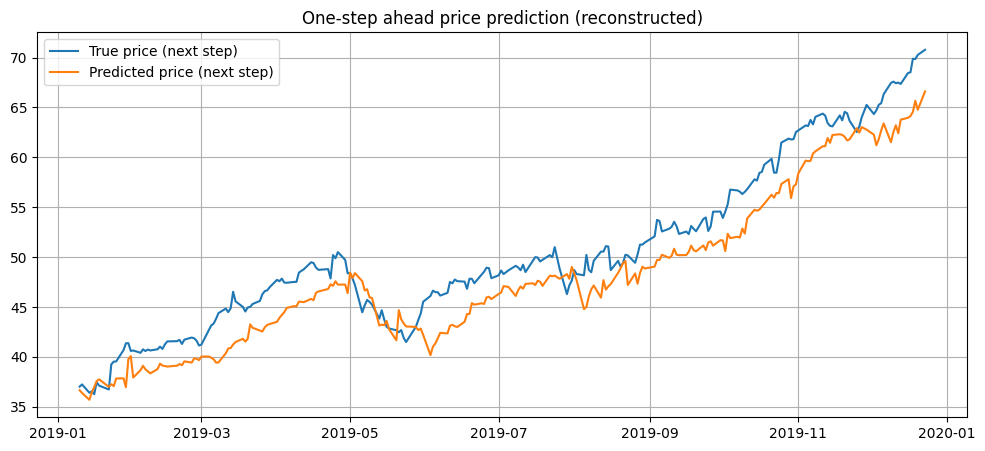

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# --- Load data ---
df = pd.read_csv(
    "C:/Users/happy/Desktop/STUFF/KhPI/Semester_8/Thesis/Stock-Market-Forecasting-Component/data/processed/AAPL_2015-01-01_2020-01-01_1d_v6.csv",
    index_col=0,
    parse_dates=True
)

# --- Target: next-day return ---
df["target"] = df["close"].pct_change().shift(-1)

# IMPORTANT: align properly
df = df.dropna()

X = df.drop(columns=["target"])
y = df["target"]

# --- Time split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# --- Model ---
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

# --- 1. Return metrics ---
print("R2:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

# --- 2. Directional accuracy (VERY IMPORTANT) ---
direction_acc = np.mean(
    np.sign(pred) == np.sign(y_test)
)
print("Directional accuracy:", direction_acc)

# --- 3. Baseline comparison ---
baseline_pred = np.zeros_like(y_test)
print("Baseline MSE:", mean_squared_error(y_test, baseline_pred))

# --- 4. Price reconstruction (for visualization only) ---
test_df = df.iloc[-len(y_test):].copy()

test_df["pred_return"] = pred
test_df["true_return"] = y_test.values

test_df["pred_price"] = test_df["close"] * (1 + test_df["pred_return"])
test_df["true_price"] = test_df["close"] * (1 + test_df["true_return"])

# --- Plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_df["true_price"], label="True price (next step)")
plt.plot(test_df["pred_price"], label="Predicted price (next step)")
plt.legend()
plt.title("One-step ahead price prediction (reconstructed)")
plt.grid()
plt.show()